# Toy Datasets

`sc_flow.dataset.toy_data.get_toy_data` provides six synthetic datasets for quick experimentation.
Each is returned as a `scanpy.AnnData` object with `.X` as the data matrix and labels
in `.obsm['Y']` (or `.obsm['row_cluster']` for the checkerboard).

| Name | Shape | Labels |
|------|-------|--------|
| `blobs` | (n, n_features) | discrete cluster ids |
| `moons` | (n, 2) | 0 / 1 |
| `circles` | (n, 2) | 0 / 1 |
| `s_curve` | (n, 3) | continuous manifold param |
| `swiss_roll` | (n, 3) | continuous manifold param |
| `checkerboard` | (n, n_features) | row & col clusters |


In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

from sc_flow.dataset.toy_data import get_toy_dataset

## 1. Overview: all six datasets at a glance


In [3]:
datasets_2d = {
    "blobs": get_toy_dataset("blobs", n_samples=800, n_features=2, centers=4).adata,
    "moons": get_toy_dataset("moons", n_samples=800, noise=0.08).adata,
    "circles": get_toy_dataset("circles", n_samples=800, noise=0.05).adata,
}
datasets_3d = {
    "s_curve": get_toy_dataset("s_curve", n_samples=10_000).adata,
    "swiss_roll": get_toy_dataset("swiss_roll", n_samples=10_000).adata,
}

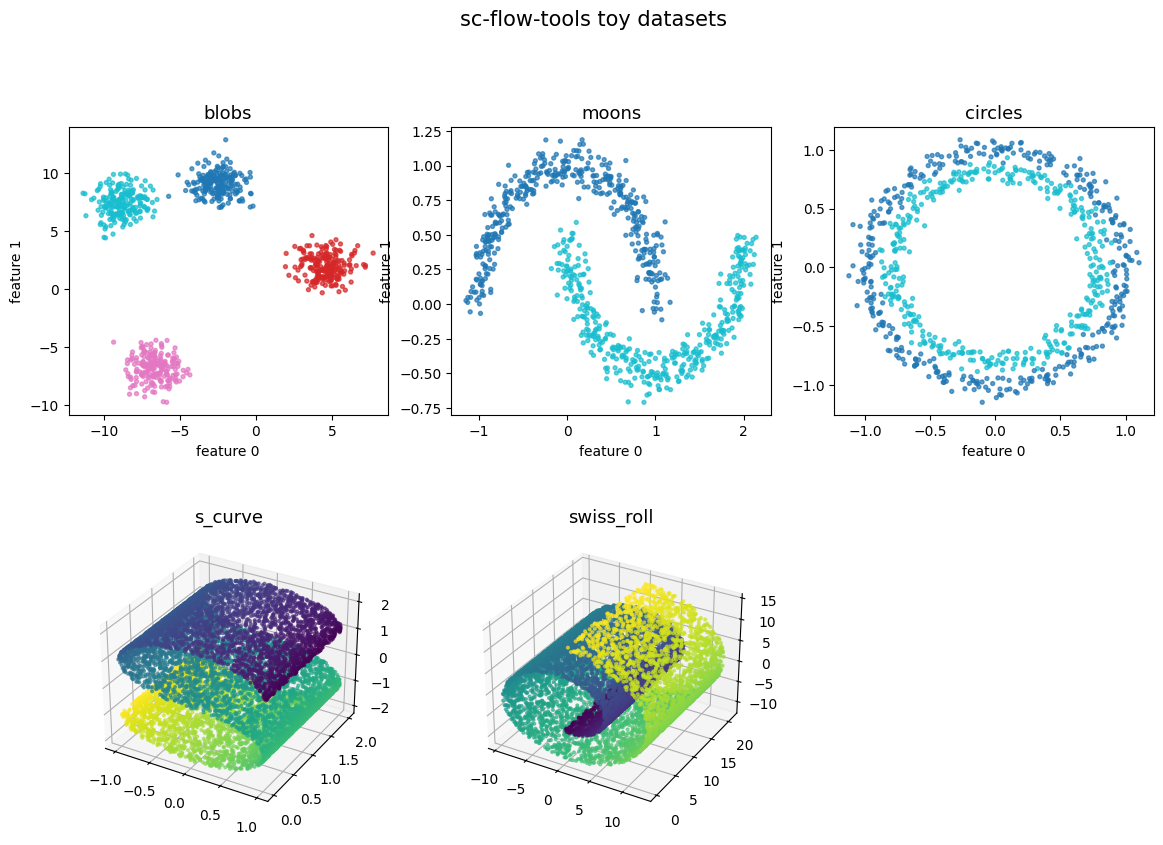

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(14, 9))
fig.subplots_adjust(hspace=0.4)

# ── Row 0: 2-D datasets ───────────────────────────────────────────────────
for ax, (name, adata) in zip(axes[0], datasets_2d.items(), strict=False):
    X = np.array(adata.X)
    labels = np.array(adata.obsm["Y"]).ravel().astype(float)
    ax.scatter(X[:, 0], X[:, 1], c=labels, cmap="tab10", s=8, alpha=0.7)
    ax.set_title(name, fontsize=13)
    ax.set_xlabel("feature 0")
    ax.set_ylabel("feature 1")

# ── Row 1, cols 0-1: 3-D manifolds ───────────────────────────────────────
for ax_flat, (name, adata) in zip(axes[1, :2], datasets_3d.items(), strict=False):
    pos = ax_flat.get_position()
    ax_flat.remove()
    ax3 = fig.add_axes([pos.x0, pos.y0, pos.width, pos.height], projection="3d")
    X = np.array(adata.X)
    col = np.array(adata.obsm["Y"]).ravel().astype(float)
    ax3.scatter(X[:, 0], X[:, 1], X[:, 2], c=col, cmap="viridis", s=4, alpha=0.6)
    ax3.set_title(name, fontsize=13)

axes[1, 2].axis("off")  # Dont know how to plot checkboard

plt.suptitle("sc-flow-tools toy datasets", fontsize=15, y=1.01)
plt.show()

## 2. Constructor arguments and AnnData fields


### 2.1 `blobs` — Gaussian clusters

```python
get_toy_dataset('blobs',
    n_samples=1000,   # total points
    n_features=2,     # dimensionality
    centers=3,        # number of clusters
    cluster_std=1.0,  # spread of each cluster
    random_state=42)
```


In [5]:
adata = get_toy_dataset("blobs", n_samples=500, n_features=2, centers=4, cluster_std=0.5).adata
adata.uns["dataset_info"]

{'name': 'blobs',
 'random_state': 42,
 'No of centers': 4,
 'cluster_std': 0.5,
 'center_box': (-10.0, 10.0),
 'shuffle': True,
 'centers': {'0': array([-2.50919762,  9.01428613]),
  '1': array([4.63987884, 1.97316968]),
  '2': array([-6.87962719, -6.88010959]),
  '3': array([-8.83832776,  7.32352292])}}

### 2.2 `moons` — two interleaving half-circles

```python
get_toy_dataset('moons',
    n_samples=1000,
    noise=0.05,
    random_state=42)
```


In [6]:
adata = get_toy_dataset("moons", n_samples=1000, noise=0.05, random_state=42).adata
adata.uns["dataset_info"]

{'name': 'moons', 'random_state': 42, 'noise': 0.05, 'shuffle': True}

### 2.3 `circles` — two concentric circles

```python
get_toy_dataset('circles',
    n_samples=1000,
    noise=0.05,
    factor=0.5) #ratio of inner-circle radius to outer-circle radius.
```


In [7]:
adata = get_toy_dataset("circles", n_samples=1000, noise=0.05, factor=0.5).adata
adata.uns["dataset_info"]

{'name': 'circles',
 'random_state': 42,
 'noise': 0.05,
 'factor': 0.5,
 'shuffle': True}

### 2.4 `s_curve` and `swiss_roll` — 3-D manifolds

Both return **3-D** data (`X.shape == (n, 3)`).
`.obsm['Y']` holds a **continuous** manifold parameter (float), not a class label.
Useful for testing manifold-aware transport.


```python
get_toy_dataset('s_curve',
    n_samples=1000,
    noise=0.05,
    random_state=42)
```

```python
get_toy_dataset('swiss_roll',
    random_state = 42,
    n_samples = 1000,
    noise = 0.0,
    hole = False,
    )
```

In [8]:
sc_adata = get_toy_dataset("s_curve", n_samples=500).adata
sr_adata = get_toy_dataset("swiss_roll", n_samples=500).adata
print("s_curve  X.shape:", sc_adata.X.shape, "  Y dtype:", np.array(sc_adata.obsm["Y"]).dtype)
print("swiss_roll X.shape:", sr_adata.X.shape)

s_curve  X.shape: (500, 3)   Y dtype: float64
swiss_roll X.shape: (500, 3)


In [9]:
sc_adata.uns["dataset_info"]

{'name': 'scurve', 'random_state': 42, 'noise': 0.0}

In [10]:
sr_adata.uns["dataset_info"]

{'name': 'swissroll', 'random_state': 42, 'noise': 0.0, 'hole': False}

### 2.5 `checkerboard` — biclustering pattern

```python
get_toy_dataset('checkerboard',
    n_samples=1000,
    n_features=2,
    n_clusters=3,   # or (n_row_clusters, n_col_clusters)
    noise=0.0,
)
```

Labels are in `.obsm['row_cluster']` and `.varm['col_cluster']`.


In [11]:
cb = get_toy_dataset("checkerboard", n_samples=600, n_features=2, n_clusters=3).adata
print("row_cluster shape:", cb.obsm["row_cluster"].shape)
print("col_cluster shape:", cb.varm["col_cluster"].shape)

row_cluster shape: (600, 9)
col_cluster shape: (2, 9)


In [12]:
cb.uns["dataset_info"]

{'name': 'checkerboard',
 'random_state': 42,
 'extra_info': 'The row & col cluster original shape is (n_clusters, X.shape[0]) & (n_clusters, X.shape[1]) respectively.',
 'n_clusters': 3,
 'noise': 0.0,
 'minval': 10.0,
 'maxval': 100.0,
 'shuffle': True}